In [ ]:
# Notebook ini mengonversi jumlah penyewaan menjadi kategori diskrit (Low, Medium, High Demand) 
# untuk memprediksi tingkat keramaian di waktu tertentu.

# Proses ini menggunakan algoritma Decision Tree atau K-NN guna menghasilkan model 
# yang membantu perusahaan mengantisipasi stok sepeda secara efektif.

In [5]:
import sys
!{sys.executable} -m pip install scikit-learn feature-engine

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/9f/c4/0ab22726a04ede56f689476b760f98f8f46607caecff993017ac1b64aa5d/scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Obtaining dependency information for feature-engine from https://files.pythonhosted.org/packages/b1/04/06f8f92663e98f000d427a3e2ce20a2bcdc0119e30b4f97b918ee0f80fe4/feature_engine-1.9.3-py3-none-any.whl.metadata
  Using cached feature_engine-1.9.3-py3-none-any.whl.metadata (10 kB)
  Obtaining dependency information for scipy>=1.10.0 from https://files.pythonhosted.org/packages/c2/7f/acbd28c97e990b421af7d6d6cd416358c9c293fc958b8529e0bd5d2a2a19/scipy-1.16.3-cp312-cp312-win_amd64.whl.metadata
  Using cached scipy-1.16.3-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Obtaining dependency information for joblib>=1.3.0 from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\REYHAN\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\scipy\\integrate\\_ivp\\__init__.py'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
# Library sesuai proposal
from feature_engine.encoding import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [54]:
# 1. Load Data
df = pd.read_csv('../data/hour.csv')

# Membuat salinan dataset
df_class = df.copy()
print(f"✓ Berhasil membuat salinan dataset. Jumlah baris: {df_class.shape[0]}")

✓ Berhasil membuat salinan dataset. Jumlah baris: 17379


In [ ]:
# 2. Konversi 'cnt' menjadi Kelas Diskrit (Target) 
def categorize_demand(cnt):
    if cnt < 50:
        return 'Low Demand'
    elif 50 <= cnt < 200:
        return 'Medium Demand'
    else:
        return 'High Demand' # Sesuai logika cnt >= 200

df_class['demand_category'] = df_class['cnt'].apply(categorize_demand)
print("✓ Pelabelan selesai. Contoh 5 baris pertama dengan kategori:")
display(df_class[['cnt', 'demand_category']].head())

✓ Pelabelan selesai. Contoh 5 baris pertama dengan kategori:


,cnt,demand_category
0,16,Low Demand
1,40,Low Demand
2,32,Low Demand
3,13,Low Demand
4,1,Low Demand


In [ ]:
# 3. Definisi Fitur dan Target
# Kita masukkan variabel kategorikal untuk diproses oleh feature-engine, tapi sblm itu mengubah 
# data yang integer jadi object supaya terbaca
df_class[['season', 'weathersit']] = df_class[['season', 'weathersit']].astype(object)
features = ['season', 'hr', 'holiday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed']
X = df_class[features]
y = df_class['demand_category']

In [ ]:
# 4. Feature Engineering menggunakan Feature-Engine 
# Menggunakan OneHotEncoder untuk variabel kategorikal sesuai proposal 
encoder = OneHotEncoder(variables=['season', 'weathersit'])
X_encoded = encoder.fit_transform(X)
print(f"✓ Feature Engineering selesai. Jumlah fitur setelah encoding: {X_encoded.shape[1]}")

✓ Feature Engineering selesai. Jumlah fitur setelah encoding: 14


In [ ]:
# 5. Split Data (Training & Testing)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [68]:
# 6. Pelatihan Model Decision Tree 
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

# Melakukan prediksi pada data test (sebagai simulasi input data baru)
y_pred = model_dt.predict(X_test)

Total Akurasi Model: 78.71%


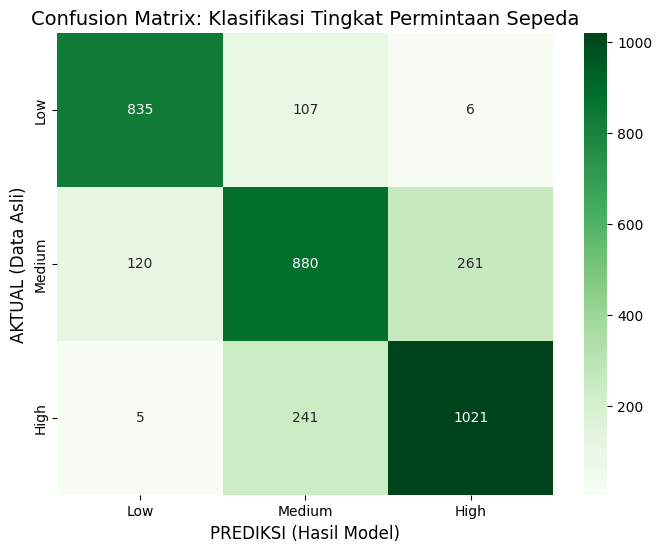


Detail Laporan Klasifikasi:
               precision    recall  f1-score   support

  High Demand       0.79      0.81      0.80      1267
   Low Demand       0.87      0.88      0.88       948
Medium Demand       0.72      0.70      0.71      1261

     accuracy                           0.79      3476
    macro avg       0.79      0.79      0.79      3476
 weighted avg       0.79      0.79      0.79      3476



In [69]:
# 7. EVALUASI: CONFUSION MATRIX & REPORT
# Print Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Total Akurasi Model: {accuracy * 100:.2f}%")

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=['Low Demand', 'Medium Demand', 'High Demand'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])

plt.title("Confusion Matrix: Klasifikasi Tingkat Permintaan Sepeda", fontsize=14)
plt.xlabel("PREDIKSI (Hasil Model)", fontsize=12)
plt.ylabel("AKTUAL (Data Asli)", fontsize=12)
plt.show()



print("\nDetail Laporan Klasifikasi:")
print(classification_report(y_test, y_pred))

In [ ]:
# 8. EKSPOR HASIL (FOLDER BARU)
print("\n--- TAHAP 8: Menyimpan Hasil ke CSV ---")
output_dir = '../data/hasil_klasifikasi'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"[LOG] Membuat folder baru di: {output_dir}")

# Menggabungkan fitur test dengan hasil prediksi untuk diekspor
output_df = X_test.copy()
output_df['Actual_Demand'] = y_test
output_df['Predicted_Demand'] = y_pred

output_file = f"{output_dir}/classification_result.csv"
output_df.to_csv(output_file, index=False)
print(f"[OK] Selesai! Hasil klasifikasi disimpan di: {output_file}")


--- TAHAP 5: Menyimpan Hasil ke CSV ---
[OK] Selesai! Hasil klasifikasi disimpan di: ../data/hasil_klasifikasi/classification_result.csv
